---
title: CASALS L1B Waveform Data Tutorial
date: 2026-02-10
github: https://github.com/cryointhecloud/CryocloudWebsite
subject: Tutorial
authors:
  - name: Jeffrey Lee
    affiliations:
      - id: NASA
        institution: NASA GSFC
    corresponding: true
    email: jeffrey.e.lee@nasa.gov
  - name: John Yorks
    affiliations:
      - id: NASA
    email: john.e.yorks@nasa.gov
  - name: Tasha Snow
    affiliations:
      - University of Maryland
      - id: NASA
    email: tsnow03@umd.edu
    orcid: 0000-0001-5697-5470
license: MIT
---

This tutorial demonstrates how to access and visualize NASA CASALS (Concurrent Artificially-intelligent Spectrometry and Adaptive Lidar System) L1B geolocated waveform data from AWS S3.

## About CASALS L1B Data

**Data Organization:**
- **Pulse**: A single laser 'shot' with unique timestamp and Tx/Rx waveforms (up to 256 possible wavelengths/channels)
- **Track**: A collection of pulses with the same wavelength, illuminates surface in along-track direction (direction of flight)
- **Sweep**: A collection of coincident pulses spanning available wavelengths, illuminates surface in across-track direction

**File Naming Convention:** `casals_LEVEL_UTC_VERSIONID_REV.FORMAT`
- Example: `casals_l1b_20241118T165452_001_02.h5`
- **LEVEL**: Product level (l1a, l1b, l2a...)
- **UTC**: J2000 UTC start time (yyyymmddThhmmss)
- **VERSIONID**: Version number (001, 002...)
- **REV**: Revision number (01, 02...)
- **FORMAT**: File format (.h5)

**File Sizes (per ~20-30 seconds of data):**
| File Type | Size | Notes |
|-----------|------|-------|
| L0 (TDMS) | 19 GB | Native LabView |
| L1A (H5) | 13 GB | Internal compression |
| ARD (H5) | 100 MB | No waveforms saves space |
| **L1B (H5)** | **14 GB** | **Contains reference height and waveforms** |

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import s3fs

## 1. List available data files

First, let's see what L1B files are available in the S3 bucket. We are only looking at the first 10 files and showing only hdf5.

In [23]:
# Configure S3 client for anonymous (public) access
s3 = boto3.client('s3', 
                  region_name='us-west-2',
                  config=Config(signature_version=UNSIGNED))

# Bucket information
bucket_name = 'casals-data'
prefix = 'lidar/'

# List files
print("Available CASALS data files:\n")
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix, MaxKeys=10)

if 'Contents' in response:
    for obj in response['Contents']:
        # Only show H5 files
        if obj['Key'].endswith('.h5'):
            print(f"{obj['Key']}")
            print(f"  Size: {obj['Size'] / (1024**3):.2f} GB")
            print(f"  Last Modified: {obj['LastModified']}\n")
else:
    print("No files found")

Available CASALS data files:

lidar/2024-11-12/casals_l1b_20241112T163923_001_02.h5
  Size: 3.04 GB
  Last Modified: 2025-12-11 15:02:45+00:00

lidar/2024-11-12/casals_l1b_20241112T163934_001_02.h5
  Size: 1.30 GB
  Last Modified: 2025-12-11 15:02:45+00:00

lidar/2024-11-12/casals_l1b_20241112T163941_001_02.h5
  Size: 1.57 GB
  Last Modified: 2025-12-11 15:02:45+00:00

lidar/2024-11-12/casals_l1b_20241112T164250_001_02.h5
  Size: 12.98 GB
  Last Modified: 2025-12-11 15:09:39+00:00

lidar/2024-11-12/casals_l1b_20241112T164315_001_02.h5
  Size: 12.95 GB
  Last Modified: 2025-12-11 15:09:39+00:00

lidar/2024-11-12/casals_l1b_20241112T164340_001_02.h5
  Size: 12.92 GB
  Last Modified: 2025-12-11 15:09:39+00:00

lidar/2024-11-12/casals_l1b_20241112T164406_001_02.h5
  Size: 13.02 GB
  Last Modified: 2025-12-11 15:09:39+00:00



Alternatively, you can choose to use s3fs instead.

In [26]:
# Create filesystem object for anonymous access
fs = s3fs.S3FileSystem(anon=True)

# Bucket information
bucket_name = 'casals-data'
prefix = 'lidar/'

# List files in the bucket
print("Available CASALS data files:\n")
files = fs.ls(f'{bucket_name}/{prefix}')

for file_path in files[:20]:  # Limit to first 20
    print(f"{file_path}")
    # Get file info for size
    info = fs.info(file_path)
    print(f"  Size: {info['size'] / (1024**3):.2f} GB")
    print(f"  Last Modified: {info.get('LastModified', 'N/A')}\n")

Available CASALS data files:

casals-data/lidar/
  Size: 0.00 GB
  Last Modified: N/A

casals-data/lidar/00README_CASALS_GE_Tours.txt
  Size: 0.00 GB
  Last Modified: 2026-01-20 18:35:40+00:00

casals-data/lidar/2024-11-12
  Size: 0.00 GB
  Last Modified: N/A

casals-data/lidar/2024-11-18
  Size: 0.00 GB
  Last Modified: N/A

casals-data/lidar/CASALS_2024-11-12_All_Amplitudes_Tour.m4v
  Size: 7.50 GB
  Last Modified: 2026-01-20 18:35:40+00:00

casals-data/lidar/CASALS_2024-11-12_All_Heights_Tour.m4v
  Size: 7.50 GB
  Last Modified: 2026-01-20 18:35:40+00:00

casals-data/lidar/CASALS_2024-11-18_All_Amplitudes_Tour.m4v
  Size: 14.01 GB
  Last Modified: 2026-01-20 18:35:40+00:00

casals-data/lidar/CASALS_2024-11-18_All_Heights_Tour.m4v
  Size: 14.00 GB
  Last Modified: 2026-01-20 18:35:40+00:00



## 2. Open dataset with lazy loading

Using xarray with h5netcdf engine allows us to access specific subsets without loading the entire ~14 GB file into memory. 
```{tip}
Lazy loading means the data stays on S3 until you explicitly call `.load()` or perform operations that require the actual data values.
```

In [7]:
%%time
# S3 url of the file to read
s3url = 's3://casals-data/lidar/2024-11-18/casals_l1b_20241118T172656_001_02.h5'

# Open dataset with lazy loading - doesn't load data into memory yet
# storage_options={'anon': True} enables anonymous (public) access
ds = xr.open_dataset(s3url, engine='h5netcdf', storage_options={'anon': True})

print("Dataset opened successfully! (data not yet loaded)")

Dataset opened successfully! (data not yet loaded)
CPU times: user 7.19 s, sys: 3.87 s, total: 11.1 s
Wall time: 39.4 s


<timed exec>:6: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.


## 3. Inspect Dataset Structure

Let's examine the L1B file structure and key variables without loading the full data.
```{note}
This inspection step is free - we're only reading metadata, not the actual waveform data!
```

In [8]:
# Inspect the overall structure
print("Dataset structure:")
print(ds)

print("\n" + "="*60)
print("Data variables (measurements and derived products):")
print("="*60)
for var in list(ds.data_vars):
    print(f"  {var}")

print("\n" + "="*60)
print("Dimensions:")
print("="*60)
for dim, size in dict(ds.dims).items():
    print(f"  {dim}: {size}")

print("\n" + "="*60)
print("Coordinates (indices for data organization):")
print("="*60)
for coord in list(ds.coords):
    print(f"  {coord}")

Dataset structure:
<xarray.Dataset> Size: 21GB
Dimensions:                           (delta_time: 3604480, rx_bins: 2728,
                                       phony_dim_0: 14080, phony_dim_1: 256,
                                       tx_bins: 80)
Coordinates:
  * delta_time                        (delta_time) float64 29MB 2.172e+08 ......
  * rx_bins                           (rx_bins) int64 22kB 0 1 2 ... 2726 2727
  * tx_bins                           (tx_bins) int64 640B 0 1 2 3 ... 77 78 79
Dimensions without coordinates: phony_dim_0, phony_dim_1
Data variables: (12/65)
    bg_mean                           (delta_time) float64 29MB ...
    bg_std                            (delta_time) float64 29MB ...
    bin_size                          (delta_time) float64 29MB ...
    dac                               (delta_time) float64 29MB ...
    geoid                             (delta_time) float32 14MB ...
    geoid_free2mean                   (delta_time) float32 14MB ...
    ...

/tmp/ipykernel_127/3837883000.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in dict(ds.dims).items():


## 4. Examine Key Variables

**Important L1B datasets:**

| Variable | Description |
|----------|-------------|
| `tx_waveform` | Transmit waveform data |
| `rx_waveform` | Receive waveform data (contains surface returns) |
| `refh` | Reference height - geolocated height of the waveform bin with maximum amplitude (WGS84 ellipsoidal height) |
| `tx_bins` | List of Tx waveform bin indices |
| `rx_bins` | List of Rx waveform bin indices |
| `delta_time` | Laser transmit time in GPS seconds since 2018-01-01 |
| `sweep_num` | Unique 0-based counter for each sweep |
| `track_num` | Track (or channel) number |
```{important}
The reference height (`refh`) is determined by finding the waveform bin with the maximum amplitude.
```

In [9]:
# Check shapes of key waveform variables
if 'tx_waveform' in ds:
    print(f"tx_waveform shape: {ds.tx_waveform.shape}")
    print(f"tx_waveform dims: {ds.tx_waveform.dims}")
    print(f"  -> Dimensions: (pulses × bins)")

if 'rx_waveform' in ds:
    print(f"\nrx_waveform shape: {ds.rx_waveform.shape}")
    print(f"rx_waveform dims: {ds.rx_waveform.dims}")
    print(f"  -> Dimensions: (pulses × bins)")

if 'refh' in ds:
    print(f"\nrefh (reference height) shape: {ds.refh.shape}")
    print(f"refh dims: {ds.refh.dims}")
    print(f"  -> One reference height per pulse")

tx_waveform shape: (3604480, 80)
tx_waveform dims: ('delta_time', 'tx_bins')
  -> Dimensions: (pulses × bins)

rx_waveform shape: (3604480, 2728)
rx_waveform dims: ('delta_time', 'rx_bins')
  -> Dimensions: (pulses × bins)

refh (reference height) shape: (3604480,)
refh dims: ('delta_time',)
  -> One reference height per pulse


## 5. Efficient Data Subsetting

**Strategy:** Load only indexing variables first (lightweight), then use them to create masks for the data you actually need. This avoids loading the full ~14 GB file when you only need a small subset.
```{admonition} Why This Matters
:class: tip
Loading indexing variables (track_num, sweep_num) is quick because they're small arrays. Using them to filter before loading waveforms save a lot of time!
```

In [10]:
track_num = ds.track_num.load()
sweep_num = ds.sweep_num.load()

print(f"Loaded indexing variables:")
print(f"  track_num: {len(track_num)} values (track/channel numbers)")
print(f"  sweep_num: {len(sweep_num)} values (sweep numbers)")
print(f"\nTrack range: {track_num.min().values} to {track_num.max().values}")
print(f"Sweep range: {sweep_num.min().values} to {sweep_num.max().values}")

Loaded indexing variables:
  track_num: 3604480 values (track/channel numbers)
  sweep_num: 3604480 values (sweep numbers)

Track range: 0 to 255
Sweep range: 0 to 14079


## 6. Select Data Subset

**Selection criteria:**
- **Tracks 0-255**: All available wavelengths/channels
- **Sweeps 1000-1001**: A small subset for visualization

This demonstrates how to efficiently extract specific pulses from the large dataset.
```{warning}
Selecting large ranges (e.g., all sweeps) will still result in large data downloads. Start small and expand as needed.
```

In [11]:
%%time
# Set the data selection parameters
track0 = 0      # Start track (channel)
track1 = 255    # End track (all channels)
sweep0 = 1000   # Start sweep
sweep1 = 1001   # End sweep (just 2 sweeps for this example)

# Create boolean mask to identify pulses matching our criteria
mask = ((track_num >= track0) & (track_num <= track1) & 
        (sweep_num >= sweep0) & (sweep_num <= sweep1))

# Get indices where mask is True
indices = np.where(mask)[0]
print(f"Found {len(indices)} matching pulses (records)")
print(f"  Tracks: {track0} to {track1}")
print(f"  Sweeps: {sweep0} to {sweep1}")

# Now load only the waveform data we need at those specific indices
# This is much faster than loading the entire dataset!
tx_waveform = ds.tx_waveform.isel(delta_time=indices).load()
rx_waveform = ds.rx_waveform.isel(delta_time=indices).load()

print(f"\nLoaded waveform data:")
print(f"  tx_waveform: {tx_waveform.shape}")
print(f"  rx_waveform: {rx_waveform.shape}")

Found 512 matching pulses (records)
  Tracks: 0 to 255
  Sweeps: 1000 to 1001

Loaded waveform data:
  tx_waveform: (512, 80)
  rx_waveform: (512, 2728)
CPU times: user 1.17 s, sys: 469 ms, total: 1.64 s
Wall time: 8.09 s


## 7. Visualize TX (Transmit) Waveforms

TX waveforms show the outgoing laser pulse characteristics. Multiple waveforms are plotted to show variation across the selected pulses.
```{note}
The transmit waveform represents the energy distribution of the laser pulse as it leaves the instrument.
```

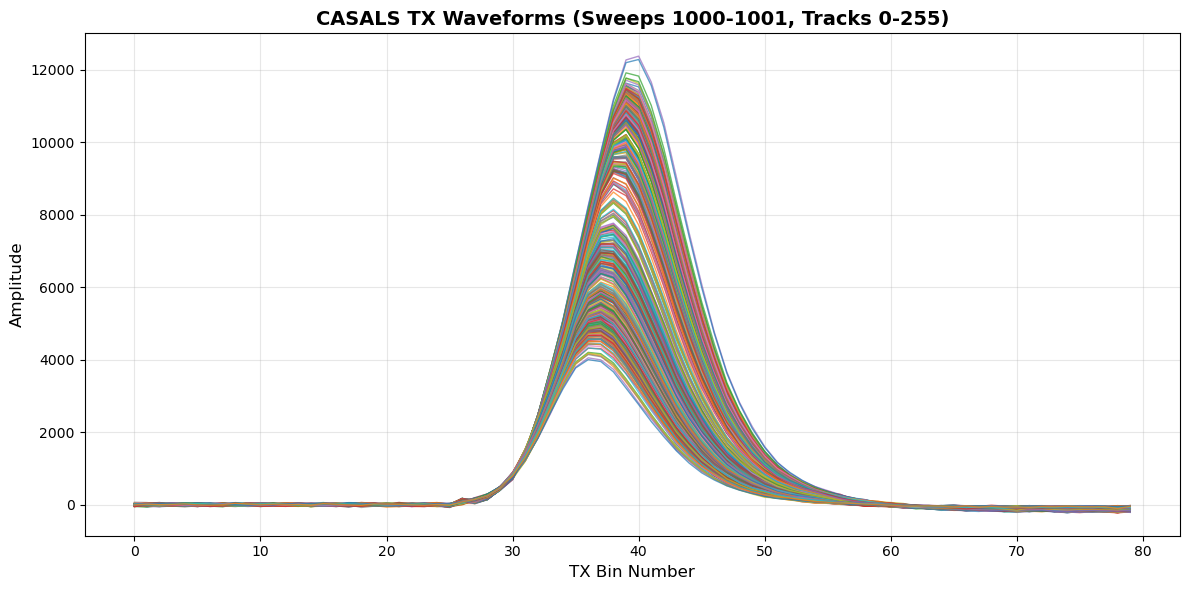

Plotted 512 TX waveforms
CPU times: user 689 ms, sys: 3.67 ms, total: 692 ms
Wall time: 692 ms


In [12]:
%%time
# Plot the Tx Waveforms
plt.figure(figsize=(12, 6))
for i in range(len(indices)):
    plt.plot(ds.tx_bins, tx_waveform[i], alpha=0.7, linewidth=1)

plt.xlabel('TX Bin Number', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title(f'CASALS TX Waveforms (Sweeps {sweep0}-{sweep1}, Tracks {track0}-{track1})', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {len(indices)} TX waveforms")

## 8. Visualize RX (Receive) Waveforms

RX waveforms show the return signal including:
- **Surface returns** (peaks in the waveform)
- Atmospheric scattering
- Background noise
```{important}
The reference height (refh) is determined from the bin with maximum amplitude in these waveforms.
```

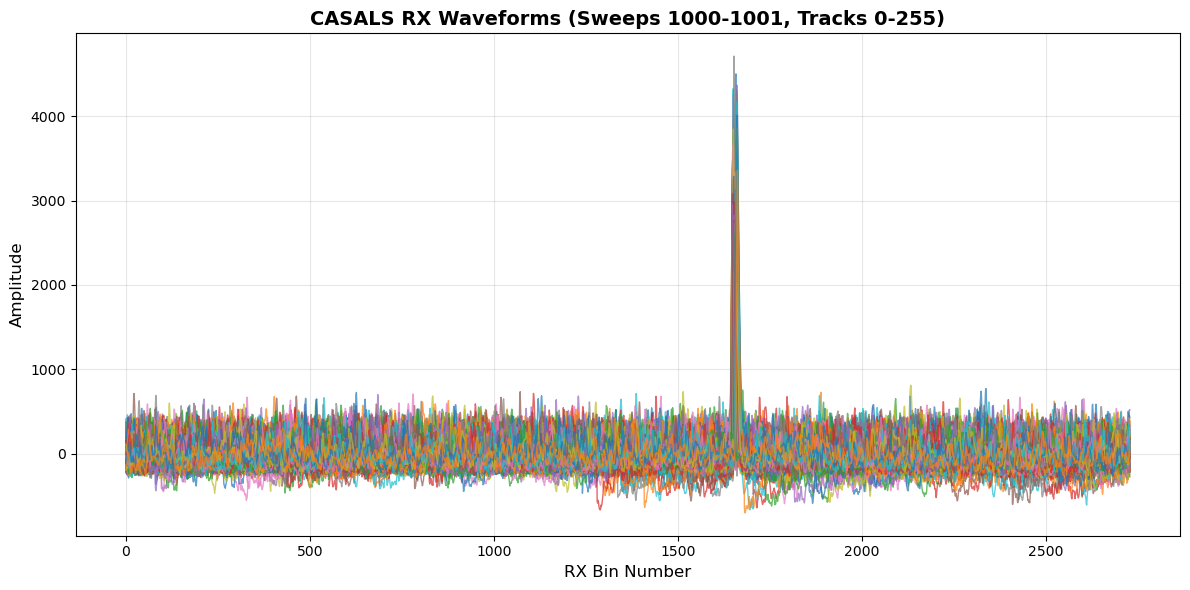

Plotted 512 RX waveforms

Note: The peaks in RX waveforms represent surface returns
The bin with maximum amplitude is used to determine the reference height (refh)
CPU times: user 2.15 s, sys: 34.2 ms, total: 2.19 s
Wall time: 2.19 s


In [13]:
%%time
# Plot the Rx Waveforms
plt.figure(figsize=(12, 6))
for i in range(len(indices)):
    plt.plot(ds.rx_bins, rx_waveform[i], alpha=0.7, linewidth=1)

plt.xlabel('RX Bin Number', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title(f'CASALS RX Waveforms (Sweeps {sweep0}-{sweep1}, Tracks {track0}-{track1})', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {len(indices)} RX waveforms")
print("\nNote: The peaks in RX waveforms represent surface returns")
print("The bin with maximum amplitude is used to determine the reference height (refh)")

## 9. Zoom into RX Waveform Peaks

**Key L1B variable: refh (reference height)**
- **Defined as**: Geolocated height of the WF bin with the maximum amplitude (WGS84 ellipsoidal height)
- The peaks we see here are the surface returns used to determine refh
- Each pulse has associated uncertainty estimates (`refh_error`)

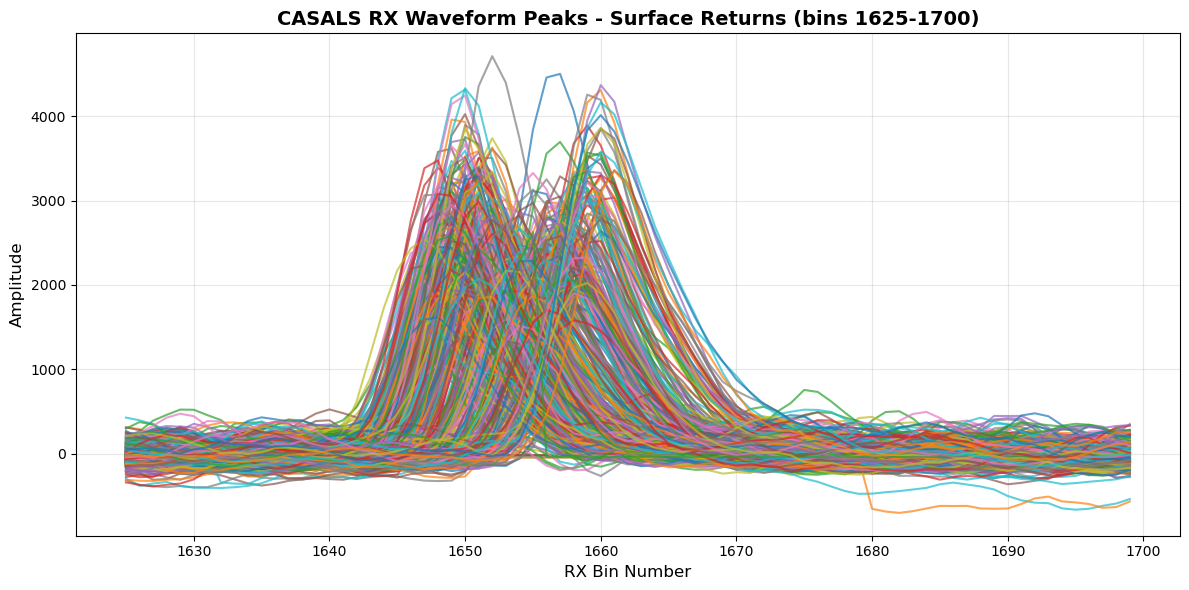

Zoomed view shows surface return peaks
The bin with maximum amplitude in this region is used for reference height
CPU times: user 728 ms, sys: 16.2 ms, total: 744 ms
Wall time: 743 ms


In [15]:
%%time
# Zoom into the peak region to see surface returns in detail
peak0 = 1625  # Start bin for zoom
peak1 = 1700  # End bin for zoom

plt.figure(figsize=(12, 6))
for i in range(len(indices)):
    plt.plot(ds.rx_bins[peak0:peak1], rx_waveform[i, peak0:peak1], 
             alpha=0.7, linewidth=1.5)

plt.xlabel('RX Bin Number', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title(f'CASALS RX Waveform Peaks - Surface Returns (bins {peak0}-{peak1})', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Zoomed view shows surface return peaks")
print(f"The bin with maximum amplitude in this region is used for reference height")

## 11. Summary of L1B CASALS data

### L1B Global Metadata Attributes:
- Names of input TDMS, L1A, GPS, ARD, and Geolocation files
- Time epoch information (J2000 UTC-A format)
- Number of Pulses, Sweeps, Tracks
- Number of Tx and Rx Waveform Bins
- Begin/End time of data
- Processing constants (speed of light, conversions, etc.)

### Key Dataset Categories:

#### 1. Identifying Datasets (per pulse)
- `delta_time`, `sweep_num`, `track_num`

#### 2. Instrument Datasets (per pulse)
- Instrument position and errors

#### 3. Range Window Datasets (per pulse)
- `rwstart`, `rwstop` (with position/errors)

#### 4. Reference Height Datasets (per pulse)
- `refh` (with position, amplitude, SNR, errors)

#### 5. Beam Angle Datasets (per pulse)
- `local_beam_azimuth`, `local_beam_elevation` (with errors)

#### 6. Solar Angle Datasets (per pulse, at refh)
- `solar_azimuth`, `solar_elevation`

#### 7. Geophysical Datasets (per pulse, at refh)
- Tide corrections, geoid, dac

#### 8. Additional Quality Datasets
- `bg_mean`, `bg_std`, `bin_size`, `good_snr`
- `range_bias_correction`, `refh_amp`, `refh_snr`, `refh_thres`
```{note}
Many correction datasets are marked **(NOT APPLIED)** - they are provided for user application as needed.
```

## 12. Accessing Data from a Local Computer

If you're running this notebook on your local machine (not in a cloud environment), you'll need to configure AWS credentials for S3 access.
```{admonition} Three Access Methods
:class: dropdown
There are three different approaches:
1. **Anonymous access** (for public buckets like CASALS)
2. **AWS credentials** (for authenticated access)
3. **Download locally first** (for slower connections or repeated analysis)
```

### Option 1: Use Anonymous (Public) Access

Since the data is in a public bucket, you can use anonymous access - same as in cloud environments!

```python
import xarray as xr

# For public buckets - same as cloud environment
s3url = 's3://casals-data/lidar/2024-11-18/casals_l1b_20241118T172656_001_02.h5'
ds = xr.open_dataset(s3url, engine='h5netcdf', storage_options={'anon': True})
```

### Option 2: Configure AWS Credentials

For accessing data that requires authentication, you have several options:

#### Method 1: Using Environment Variables

```python
# Set these in your terminal before running Python:
# export AWS_ACCESS_KEY_ID='your_access_key'
# export AWS_SECRET_ACCESS_KEY='your_secret_key'
# export AWS_DEFAULT_REGION='us-west-2'

import xarray as xr

s3url = 's3://casals-data/lidar/2024-11-18/casals_l1b_20241118T172656_001_02.h5'
ds = xr.open_dataset(s3url, engine='h5netcdf')
```

#### Method 2: Using AWS CLI Configuration
```{code-block} bash
# Run in terminal:
aws configure

# Then provide your credentials when prompted
# This stores credentials in ~/.aws/credentials
```

Then use the dataset normally in Python:

```python
import xarray as xr

s3url = 's3://casals-data/lidar/2024-11-18/casals_l1b_20241118T172656_001_02.h5'
ds = xr.open_dataset(s3url, engine='h5netcdf')
```

#### Method 3: Specify Credentials Directly
```{warning}
Not recommended for production code - credentials should not be in your code!
```

```python
storage_opts = {
    'key': 'your_access_key',
    'secret': 'your_secret_key',
    'client_kwargs': {'region_name': 'us-west-2'}
}
ds = xr.open_dataset(s3url, engine='h5netcdf', storage_options=storage_opts)
```

### Option 3: Download File Locally First

For slower internet connections or repeated analysis, download the file once:
```{tip}
This is especially useful if you'll be analyzing the same file multiple times or if you have unreliable internet connectivity.
```

```python
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import xarray as xr

# Configure S3 client
s3 = boto3.client('s3', 
                  region_name='us-west-2',
                  config=Config(signature_version=UNSIGNED))

# Download file
bucket_name = 'casals-data'
file_key = 'lidar/2024-11-18/casals_l1b_20241118T172656_001_02.h5'
local_filename = '~/Downloads/casals_l1b_local.h5' # adjust this to fit where you want your file saved on your computer

print(f"Downloading {file_key}...")
print(f"This is a ~14 GB file, it may take several minutes...")
s3.download_file(bucket_name, file_key, local_filename)
print(f"Download complete! Saved as {local_filename}")

# Now open the local file
ds = xr.open_dataset(local_filename, engine='h5netcdf')
print("Dataset opened from local file")

# Use the dataset as normal
print(ds)
```

### Required Python Packages

Install these packages on your local machine:

#### Using mamba (recommended):
```{code-block} bash
mamba install -c conda-forge xarray h5netcdf s3fs boto3 matplotlib numpy
```

#### Or using pip:
```{code-block} bash
pip install xarray h5netcdf s3fs boto3 matplotlib numpy
```

## Tutorial Complete! 🎉
```{admonition} What You Learned
:class: success
✓ Access CASALS L1B data from S3 (cloud or local)  
✓ Efficiently subset large datasets  
✓ Visualize waveform data  
✓ Work with reference heights and metadata  
✓ Configure local access methods
```

**Happy analyzing!** 🚀